# Hotel Booking Cancellation Prediction - Dataset Analysis

## Problem Overview
This dataset contains hotel booking information with the goal of predicting whether a customer will cancel their hotel booking appointment or not.

**Target Variable:**
- 1: Canceled
- 0: Not Canceled

**Evaluation Metric:** Macro-F1

**Dataset Structure:**
- Training data: train.csv (with labels)
- Test data: test.csv (without labels)
- Sample submission: sample_submission.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


## 1. Data Loading and Initial Exploration


In [2]:
# Load the datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print("Dataset Shapes:")
print(f"Training data: {train_df.shape}")
print(f"Test data: {test_df.shape}")
print(f"Sample submission: {sample_submission.shape}")
print("\n" + "="*50 + "\n")

print("Training Data Info:")
print(train_df.info())
print("\n" + "="*50 + "\n")

print("First few rows of training data:")
print(train_df.head())


Dataset Shapes:
Training data: (25417, 19)
Test data: (10858, 18)
Sample submission: (10858, 2)


Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25417 entries, 0 to 25416
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id                                    25417 non-null  int64  
 1   no_of_adults                          25417 non-null  int64  
 2   no_of_children                        25417 non-null  int64  
 3   no_of_weekend_nights                  25417 non-null  int64  
 4   no_of_week_nights                     25417 non-null  int64  
 5   type_of_meal_plan                     25417 non-null  object 
 6   required_car_parking_space            25417 non-null  int64  
 7   room_type_reserved                    25417 non-null  object 
 8   lead_time                             25417 non-null  int64  
 9   arrival_year                   

## 2. Data Quality Assessment


In [3]:
# Check for missing values
print("Missing Values in Training Data:")
missing_train = train_df.isnull().sum()
print(missing_train[missing_train > 0])

print("\nMissing Values in Test Data:")
missing_test = test_df.isnull().sum()
print(missing_test[missing_test > 0])

print("\n" + "="*50 + "\n")

# Check data types
print("Data Types:")
print(train_df.dtypes)

print("\n" + "="*50 + "\n")

# Check for duplicates
print(f"Duplicate rows in training data: {train_df.duplicated().sum()}")
print(f"Duplicate rows in test data: {test_df.duplicated().sum()}")


Missing Values in Training Data:
Series([], dtype: int64)

Missing Values in Test Data:
Series([], dtype: int64)


Data Types:
id                                        int64
no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
room_type_reserved                       object
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
market_segment_type                      object
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
label    

## 3. Target Variable Analysis


Target Variable Distribution:
label
0    17034
1     8383
Name: count, dtype: int64

Percentage distribution:
label
0    67.018137
1    32.981863
Name: count, dtype: float64


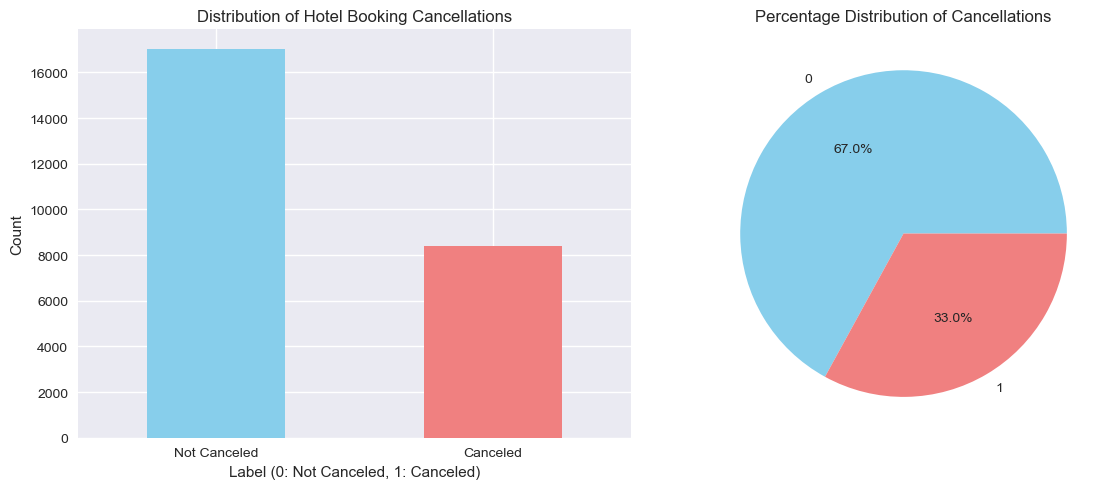


Class imbalance ratio: 0.492


In [4]:
# Analyze target variable distribution
print("Target Variable Distribution:")
label_counts = train_df['label'].value_counts()
print(label_counts)
print(f"\nPercentage distribution:")
print(label_counts / len(train_df) * 100)

# Visualize target distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
label_counts.plot(kind='bar', ax=ax1, color=['skyblue', 'lightcoral'])
ax1.set_title('Distribution of Hotel Booking Cancellations')
ax1.set_xlabel('Label (0: Not Canceled, 1: Canceled)')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['Not Canceled', 'Canceled'], rotation=0)

# Pie chart
label_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
ax2.set_title('Percentage Distribution of Cancellations')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\nClass imbalance ratio: {label_counts[1] / label_counts[0]:.3f}")


## 4. Feature Analysis - Categorical Variables


In [5]:
# Identify categorical variables
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical variables: {categorical_cols}")

# Analyze each categorical variable
for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(f"Unique values: {train_df[col].nunique()}")
    print(f"Value counts:")
    print(train_df[col].value_counts())
    
    # Calculate cancellation rate by category
    cancellation_rate = train_df.groupby(col)['label'].mean()
    print(f"\nCancellation rate by {col}:")
    print(cancellation_rate.sort_values(ascending=False))
    print("-" * 50)


Categorical variables: ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

TYPE_OF_MEAL_PLAN:
Unique values: 4
Value counts:
type_of_meal_plan
Meal Plan 1     19484
Not Selected     3595
Meal Plan 2      2335
Meal Plan 3         3
Name: count, dtype: int64

Cancellation rate by type_of_meal_plan:
type_of_meal_plan
Meal Plan 2     0.450964
Meal Plan 3     0.333333
Not Selected    0.332684
Meal Plan 1     0.314771
Name: label, dtype: float64
--------------------------------------------------

ROOM_TYPE_RESERVED:
Unique values: 7
Value counts:
room_type_reserved
Room_Type 1    19750
Room_Type 4     4227
Room_Type 6      659
Room_Type 2      497
Room_Type 5      172
Room_Type 7      107
Room_Type 3        5
Name: count, dtype: int64

Cancellation rate by room_type_reserved:
room_type_reserved
Room_Type 6    0.421851
Room_Type 4    0.341613
Room_Type 2    0.327968
Room_Type 1    0.325519
Room_Type 5    0.255814
Room_Type 7    0.224299
Room_Type 3    0.200000
Name: label, dty

## 5. Feature Analysis - Numerical Variables


In [6]:
# Identify numerical variables
numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['id', 'label']]
print(f"Numerical variables: {numerical_cols}")

# Statistical summary
print("\nStatistical Summary of Numerical Variables:")
print(train_df[numerical_cols].describe())

# Check for outliers using IQR method
print("\nOutlier Analysis (using IQR method):")
for col in numerical_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(train_df)*100:.2f}%)")


Numerical variables: ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']

Statistical Summary of Numerical Variables:
       no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights  \
count  25417.000000    25417.000000          25417.000000       25417.000000   
mean       1.843136        0.105245              0.815163           2.195184   
std        0.519663        0.404446              0.868603           1.392862   
min        0.000000        0.000000              0.000000           0.000000   
25%        2.000000        0.000000              0.000000           1.000000   
50%        2.000000        0.000000              1.000000           2.000000   
75%        2.000000        0.000000              2.000000       

## 6. Correlation Analysis


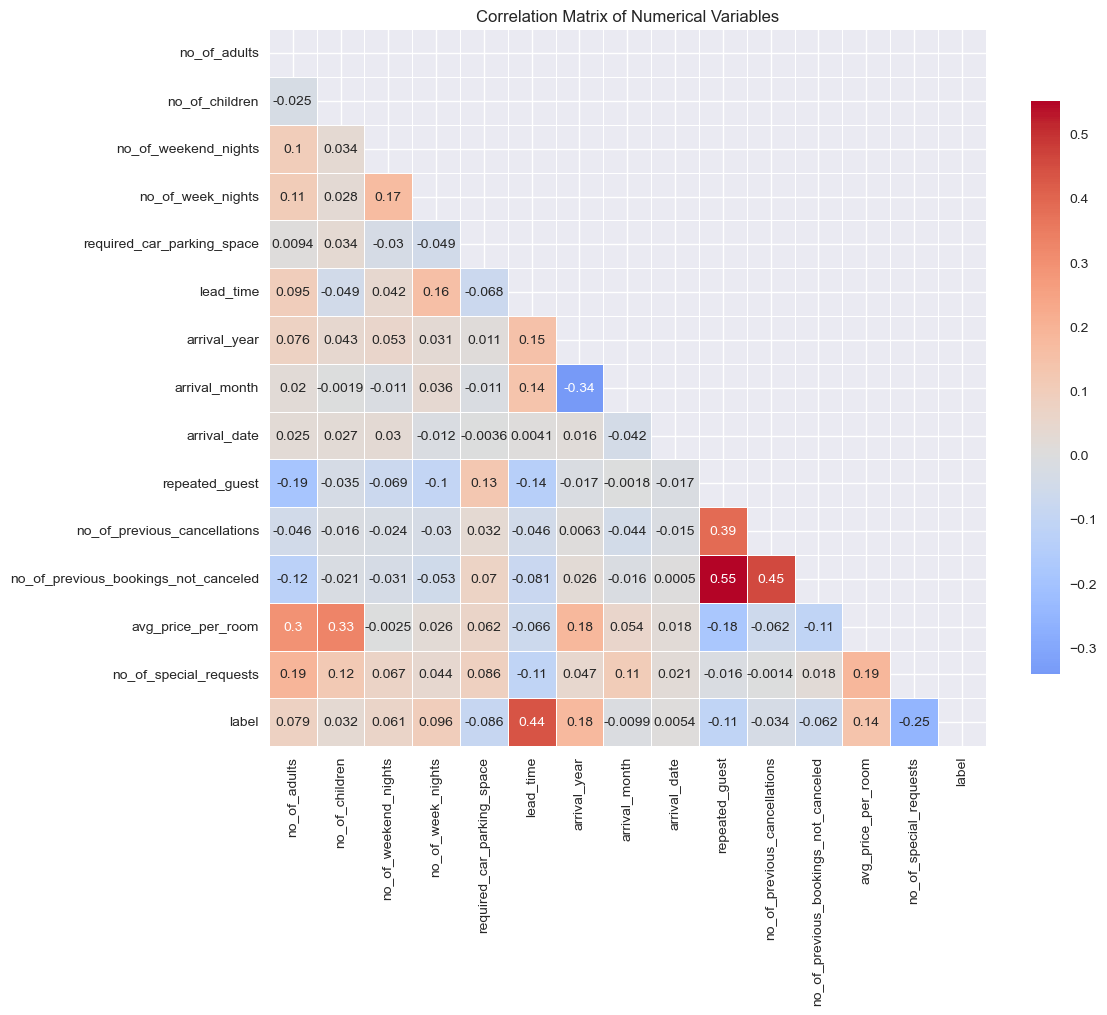


Correlations with Target Variable (label):
lead_time                               0.438723
no_of_special_requests                 -0.254359
arrival_year                            0.180863
avg_price_per_room                      0.142011
repeated_guest                         -0.109001
no_of_week_nights                       0.096237
required_car_parking_space             -0.085628
no_of_adults                            0.078907
no_of_previous_bookings_not_canceled   -0.061772
no_of_weekend_nights                    0.061226
no_of_previous_cancellations           -0.034004
no_of_children                          0.032017
arrival_month                          -0.009905
arrival_date                            0.005351
Name: label, dtype: float64


In [7]:
# Create correlation matrix for numerical variables
correlation_matrix = train_df[numerical_cols + ['label']].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

# Show correlations with target variable
print("\nCorrelations with Target Variable (label):")
correlations_with_target = correlation_matrix['label'].drop('label').sort_values(key=abs, ascending=False)
print(correlations_with_target)


## 7. Feature Distribution Analysis


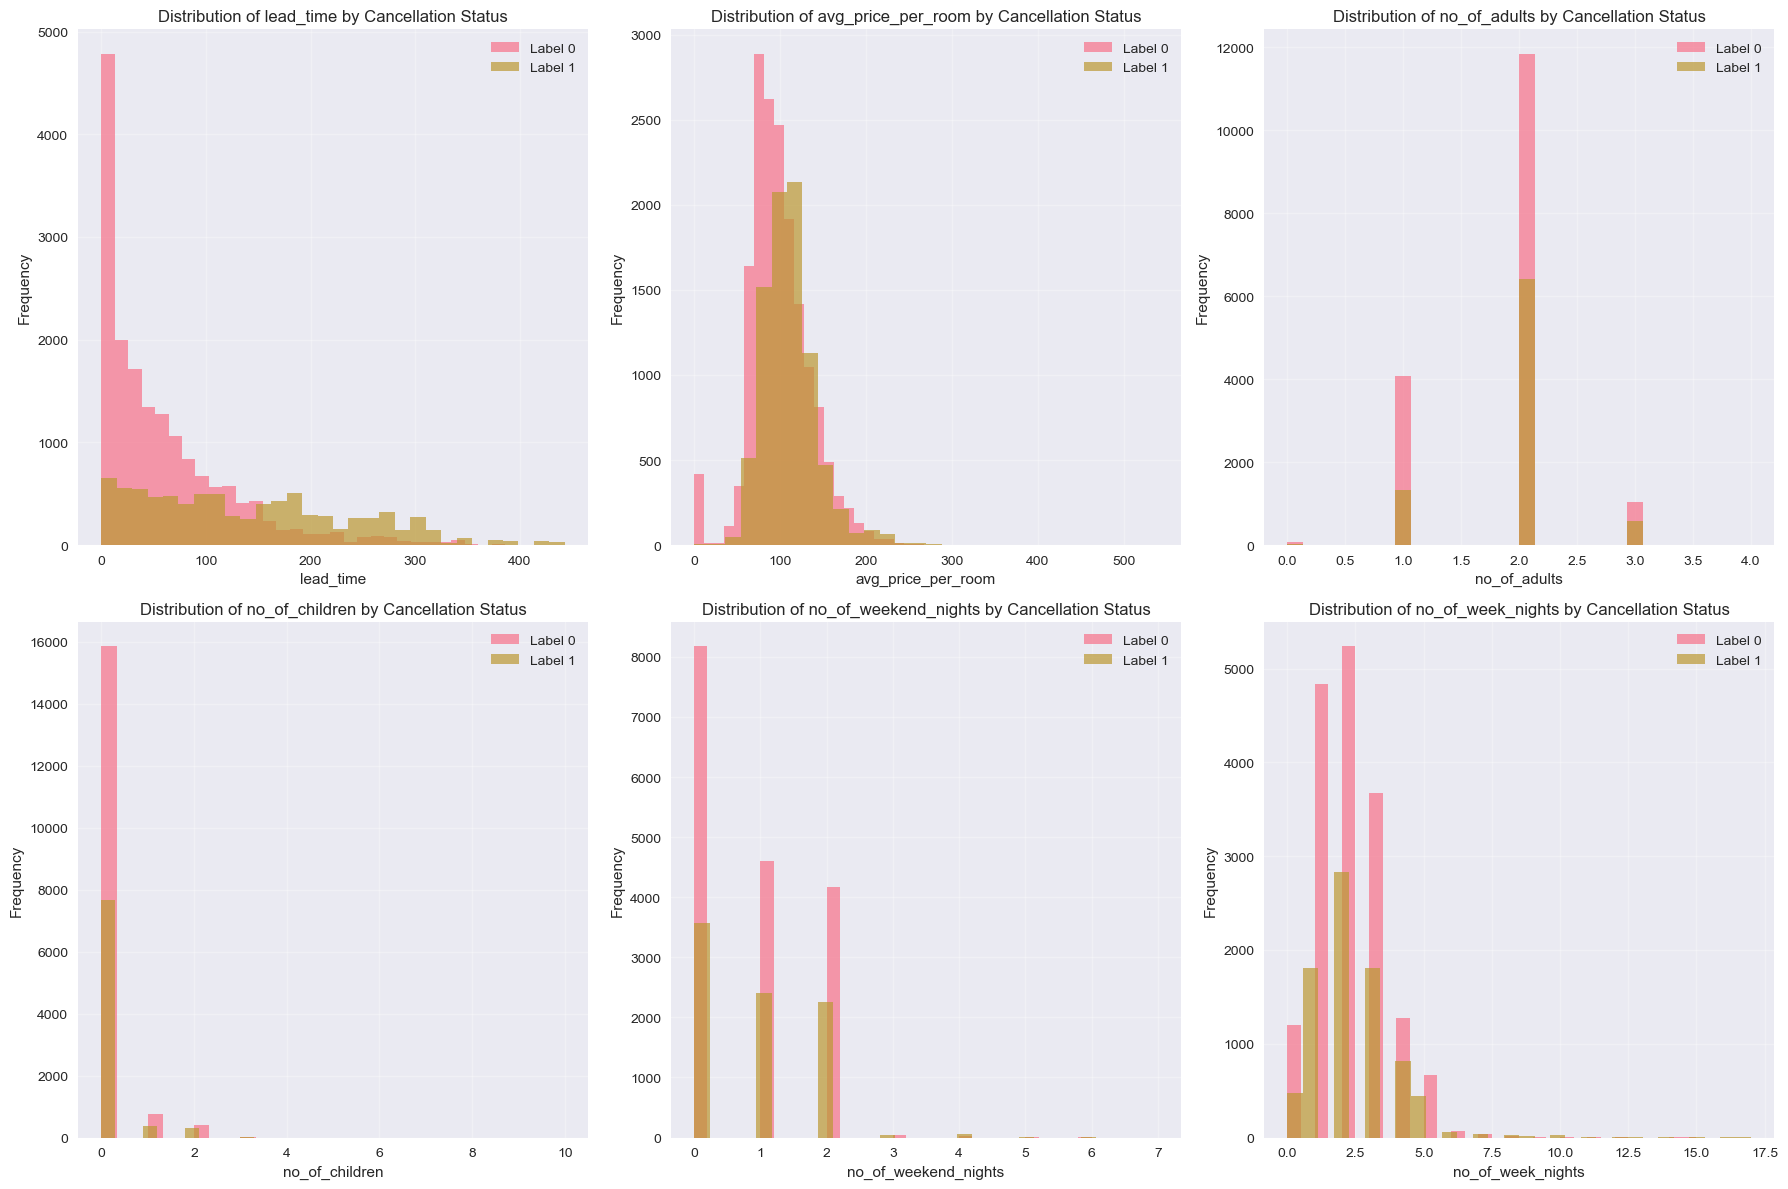

In [8]:
# Plot distributions of key numerical features
key_features = ['lead_time', 'avg_price_per_room', 'no_of_adults', 'no_of_children', 
                'no_of_weekend_nights', 'no_of_week_nights']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    if feature in train_df.columns:
        # Plot distribution by cancellation status
        for label_val in [0, 1]:
            data = train_df[train_df['label'] == label_val][feature]
            axes[i].hist(data, alpha=0.7, label=f'Label {label_val}', bins=30)
        
        axes[i].set_title(f'Distribution of {feature} by Cancellation Status')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Categorical Feature Analysis with Visualizations


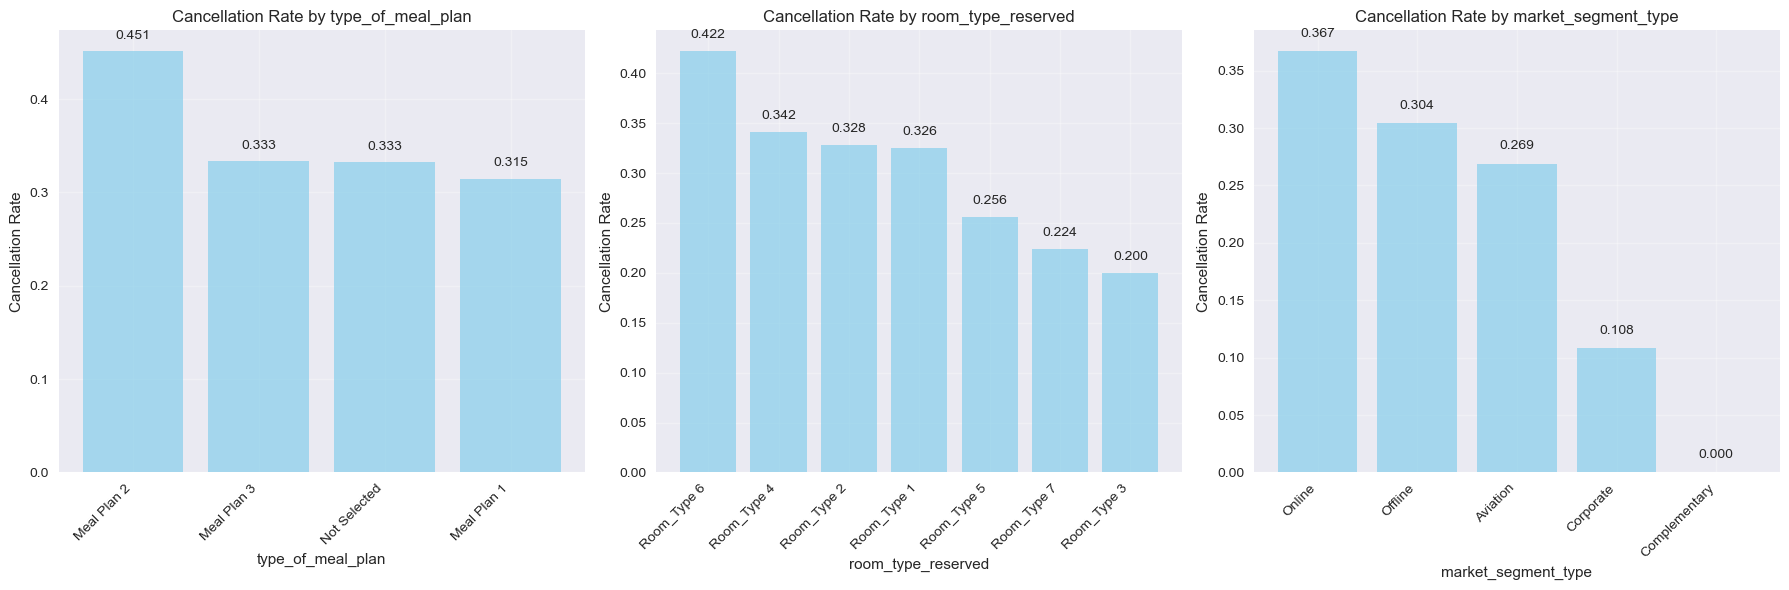

In [9]:
# Plot cancellation rates for categorical variables
categorical_cols_to_plot = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(categorical_cols_to_plot):
    if col in train_df.columns:
        # Calculate cancellation rate by category
        cancellation_by_category = train_df.groupby(col)['label'].agg(['count', 'mean']).reset_index()
        cancellation_by_category.columns = [col, 'count', 'cancellation_rate']
        
        # Sort by cancellation rate
        cancellation_by_category = cancellation_by_category.sort_values('cancellation_rate', ascending=False)
        
        # Create bar plot
        bars = axes[i].bar(range(len(cancellation_by_category)), 
                          cancellation_by_category['cancellation_rate'],
                          color='skyblue', alpha=0.7)
        
        axes[i].set_title(f'Cancellation Rate by {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Cancellation Rate')
        axes[i].set_xticks(range(len(cancellation_by_category)))
        axes[i].set_xticklabels(cancellation_by_category[col], rotation=45, ha='right')
        axes[i].grid(True, alpha=0.3)
        
        # Add value labels on bars
        for j, bar in enumerate(bars):
            height = bar.get_height()
            axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


## 9. Time-based Analysis


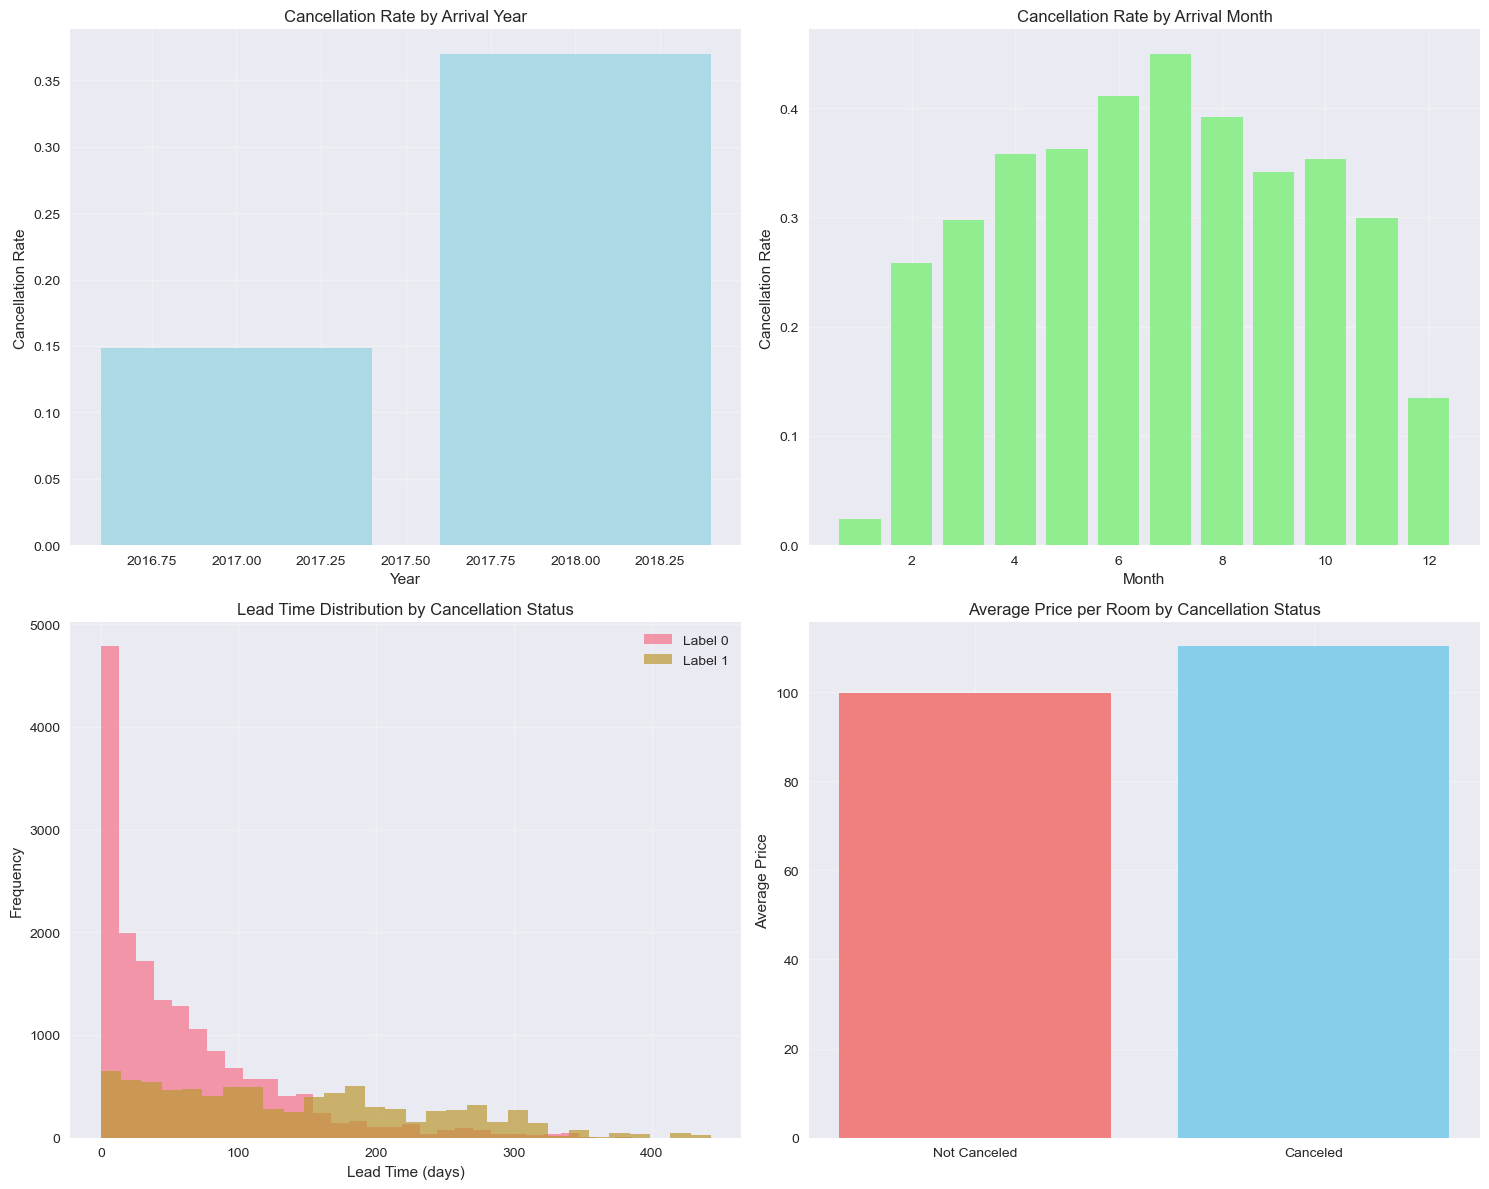

In [10]:
# Analyze cancellation patterns by time
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Cancellation rate by arrival year
year_cancellation = train_df.groupby('arrival_year')['label'].mean()
axes[0, 0].bar(year_cancellation.index, year_cancellation.values, color='lightblue')
axes[0, 0].set_title('Cancellation Rate by Arrival Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Cancellation Rate')
axes[0, 0].grid(True, alpha=0.3)

# Cancellation rate by arrival month
month_cancellation = train_df.groupby('arrival_month')['label'].mean()
axes[0, 1].bar(month_cancellation.index, month_cancellation.values, color='lightgreen')
axes[0, 1].set_title('Cancellation Rate by Arrival Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Cancellation Rate')
axes[0, 1].grid(True, alpha=0.3)

# Lead time distribution by cancellation status
for label_val in [0, 1]:
    data = train_df[train_df['label'] == label_val]['lead_time']
    axes[1, 0].hist(data, alpha=0.7, label=f'Label {label_val}', bins=30)
axes[1, 0].set_title('Lead Time Distribution by Cancellation Status')
axes[1, 0].set_xlabel('Lead Time (days)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Average price per room by cancellation status
price_by_label = train_df.groupby('label')['avg_price_per_room'].mean()
axes[1, 1].bar(['Not Canceled', 'Canceled'], price_by_label.values, color=['lightcoral', 'skyblue'])
axes[1, 1].set_title('Average Price per Room by Cancellation Status')
axes[1, 1].set_ylabel('Average Price')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Key Insights and Summary


In [11]:
# Generate summary statistics
print("=== DATASET ANALYSIS SUMMARY ===\n")

print(f"Dataset Size:")
print(f"- Training samples: {len(train_df):,}")
print(f"- Test samples: {len(test_df):,}")
print(f"- Features: {len(train_df.columns) - 2}")

print(f"\nTarget Variable Distribution:")
print(f"- Not Canceled (0): {label_counts[0]:,} ({label_counts[0]/len(train_df)*100:.1f}%)")
print(f"- Canceled (1): {label_counts[1]:,} ({label_counts[1]/len(train_df)*100:.1f}%)")
print(f"- Class imbalance ratio: {label_counts[1] / label_counts[0]:.3f}")

print(f"\nData Quality:")
print(f"- Missing values in training: {train_df.isnull().sum().sum()}")
print(f"- Missing values in test: {test_df.isnull().sum().sum()}")
print(f"- Duplicate rows in training: {train_df.duplicated().sum()}")
print(f"- Duplicate rows in test: {test_df.duplicated().sum()}")

print(f"\nTop Correlated Features with Target:")
top_correlations = correlations_with_target.head(5)
for feature, corr in top_correlations.items():
    print(f"- {feature}: {corr:.3f}")

print(f"\nKey Insights:")
print(f"- This is a binary classification problem with moderate class imbalance")
print(f"- The dataset contains both numerical and categorical features")
print(f"- No missing values detected in the dataset")
print(f"- Lead time and price appear to be important predictors")
print(f"- Evaluation metric: Macro-F1 score")

# Save the analysis
print(f"\nAnalysis completed. Ready for model development!")


=== DATASET ANALYSIS SUMMARY ===

Dataset Size:
- Training samples: 25,417
- Test samples: 10,858
- Features: 17

Target Variable Distribution:
- Not Canceled (0): 17,034 (67.0%)
- Canceled (1): 8,383 (33.0%)
- Class imbalance ratio: 0.492

Data Quality:
- Missing values in training: 0
- Missing values in test: 0
- Duplicate rows in training: 0
- Duplicate rows in test: 0

Top Correlated Features with Target:
- lead_time: 0.439
- no_of_special_requests: -0.254
- arrival_year: 0.181
- avg_price_per_room: 0.142
- repeated_guest: -0.109

Key Insights:
- This is a binary classification problem with moderate class imbalance
- The dataset contains both numerical and categorical features
- No missing values detected in the dataset
- Lead time and price appear to be important predictors
- Evaluation metric: Macro-F1 score

Analysis completed. Ready for model development!
